In [163]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from fontTools.ufoLib import deprecatedFontInfoAttributesVersion2
from sklearn.model_selection import learning_curve

X=torch.tensor([[5,30,-3.4],[34,32434,34]])
print(X.dtype)
y=np.array([5,34,3])
z=torch.from_numpy(y)
X.mean(dim=0)
X.relu()
X

torch.float32


tensor([[ 5.0000e+00,  3.0000e+01, -3.4000e+00],
        [ 3.4000e+01,  3.2434e+04,  3.4000e+01]])

In [12]:
device="cpu"
X=X.to(device)
M=torch.tensor([[2,4,3],[6,45,2]],device=device)
R=M@M.T

In [13]:
M=torch.rand(1000,1000)


tensor([[0.9235, 0.9458, 0.1774,  ..., 0.7429, 0.7095, 0.9690],
        [0.0220, 0.4846, 0.4388,  ..., 0.3720, 0.0023, 0.5823],
        [0.5142, 0.6653, 0.9754,  ..., 0.9080, 0.1497, 0.5206],
        ...,
        [0.3140, 0.9469, 0.8970,  ..., 0.5086, 0.3798, 0.0937],
        [0.6231, 0.6429, 0.1374,  ..., 0.4072, 0.4286, 0.2888],
        [0.9376, 0.8430, 0.2889,  ..., 0.3908, 0.9912, 0.1304]])

In [15]:
M@M.T
%timeit M@M.T

46.1 ms ± 5.96 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [86]:
x=torch.tensor(5.0,requires_grad=True)
f=x**2
f

tensor(25., grad_fn=<PowBackward0>)

In [87]:
f.backward()
x.grad

tensor(10.)

In [88]:
learning_rate=0.1
with torch.no_grad():
    x-=learning_rate * x.grad

In [89]:
x

tensor(4., requires_grad=True)

In [90]:
x_detached=x.detach()
x_detached-=learning_rate*x.grad

In [91]:
x_detached

tensor(3.)

In [92]:
x.grad.zero_()

tensor(0.)

In [94]:

learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
    f = x ** 2  # forward pass
    f.backward()  # backward pass
    with torch.no_grad():
        x -= learning_rate * x.grad  # gradient descent step
    x.grad.zero_()

In [98]:
x

tensor(1.0185e-09, requires_grad=True)

In [99]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
housing=fetch_california_housing()
X_train_full,X_test,y_train_full,y_test=train_test_split(housing.data,housing.target,random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [100]:
X_train=torch.FloatTensor(X_train)
X_valid=torch.FloatTensor(X_valid)
X_test=torch.FloatTensor(X_test)
means=X_train.mean(dim=0,keepdim=True)
stds=X_train.std(dim=0,keepdim=True)
X_train=(X_train-means) / stds
X_valid=(X_valid-means) / stds
X_test=(X_test-means) / stds

In [101]:
X_train

tensor([[-0.1940, -1.0778, -0.9433,  ..., -0.5729,  0.9292, -1.4221],
        [ 0.7520, -1.8688,  0.4055,  ...,  0.2052, -0.9165,  1.0966],
        [-0.4147,  0.0297,  0.8181,  ..., -0.2998,  1.3087, -1.6970],
        ...,
        [-1.2233,  0.5043, -0.5160,  ...,  0.1345, -0.7198,  1.1466],
        [-0.9355,  1.8491, -0.1088,  ..., -0.0135,  0.5217, -0.1028],
        [ 0.8958,  0.1879,  0.2995,  ..., -0.1782,  1.1213, -1.3071]])

In [102]:
y_train=torch.FloatTensor(y_train).view(-1,1)
y_valid=torch.FloatTensor(y_valid).view(-1,1)
y_test=torch.FloatTensor(y_test).view(-1,1)

In [104]:
torch.manual_seed(42)
n_features=X_train.shape[1]
w=torch.randn((n_features,1),requires_grad=True)
b=torch.tensor(0.,requires_grad=True)

In [105]:
learning_rate=0.4
n_epochs=20
for epoch in range(n_epochs):
    y_pred=X_train @ w + b
    loss=((y_pred-y_train)**2).mean()
    loss.backward()
    with torch.no_grad():
        b-=learning_rate*b.grad
        w-=learning_rate*w.grad
        b.grad.zero_()
        w.grad.zero_()
    print(f"Epoch{epoch+1}/{n_epochs},loss: {loss.item()}")

Epoch1/20,loss: 16.158456802368164
Epoch2/20,loss: 4.879387855529785
Epoch3/20,loss: 2.2552332878112793
Epoch4/20,loss: 1.3307673931121826
Epoch5/20,loss: 0.9680721163749695
Epoch6/20,loss: 0.8142691850662231
Epoch7/20,loss: 0.7417051792144775
Epoch8/20,loss: 0.7020704746246338
Epoch9/20,loss: 0.6765921115875244
Epoch10/20,loss: 0.6577966809272766
Epoch11/20,loss: 0.6426153182983398
Epoch12/20,loss: 0.6297224760055542
Epoch13/20,loss: 0.6184942722320557
Epoch14/20,loss: 0.608596920967102
Epoch15/20,loss: 0.5998217463493347
Epoch16/20,loss: 0.592018723487854
Epoch17/20,loss: 0.5850691795349121
Epoch18/20,loss: 0.578873336315155
Epoch19/20,loss: 0.573345422744751
Epoch20/20,loss: 0.5684100389480591


In [107]:
X_new=X_test[:3]
with torch.no_grad():
    y_pred=X_new @ w+b

In [108]:
y_pred

tensor([[0.8916],
        [1.6480],
        [2.6577]])

In [135]:
import torch.nn as nn
torch.manual_seed(42)
model=nn.Linear(in_features=n_features,out_features=7)

In [136]:
model.bias

Parameter containing:
tensor([ 0.1118, -0.0062,  0.2767, -0.2512,  0.0223, -0.2413,  0.1090],
       requires_grad=True)

In [137]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076],
        [ 0.3117, -0.2594,  0.3073,  0.0662,  0.2612,  0.0479,  0.1705, -0.0499],
        [ 0.2725,  0.0523, -0.1651,  0.0901, -0.1629, -0.0415, -0.1436,  0.2345],
        [-0.2791, -0.1630, -0.0998, -0.2126,  0.0334, -0.3492,  0.3193, -0.3003],
        [ 0.2730,  0.0588, -0.1148,  0.2185,  0.0551,  0.2857,  0.0387, -0.1115],
        [ 0.0950, -0.0959,  0.1488,  0.3157,  0.2044, -0.1546,  0.2041,  0.0633],
        [ 0.1795, -0.2155, -0.3500, -0.1366, -0.2712,  0.2901,  0.1018,  0.1464]],
       requires_grad=True)

In [114]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)
Parameter containing:
tensor([0.3117], requires_grad=True)


In [115]:
model(X_train[:2])

tensor([[-0.4718],
        [ 0.1131]], grad_fn=<AddmmBackward0>)

In [120]:
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
mse=nn.MSELoss()

In [121]:
def train_bgd(model,optimizer,criterion,X_train,y_train,n_epochs):
    for epoch in range(n_epochs):
        y_pred=model(X_train)
        loss=criterion(y_pred,y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item()}")

In [122]:
train_bgd(model,optimizer,mse,X_train,y_train,n_epochs)

Epoch 1/20, Loss: 4.3378496170043945
Epoch 2/20, Loss: 0.7802932858467102
Epoch 3/20, Loss: 0.6253840327262878
Epoch 4/20, Loss: 0.6060433983802795
Epoch 5/20, Loss: 0.595629870891571
Epoch 6/20, Loss: 0.5873565673828125
Epoch 7/20, Loss: 0.5802990198135376
Epoch 8/20, Loss: 0.5741381645202637
Epoch 9/20, Loss: 0.5687101483345032
Epoch 10/20, Loss: 0.5639079213142395
Epoch 11/20, Loss: 0.5596510767936707
Epoch 12/20, Loss: 0.555873692035675
Epoch 13/20, Loss: 0.5525193810462952
Epoch 14/20, Loss: 0.5495390892028809
Epoch 15/20, Loss: 0.5468899011611938
Epoch 16/20, Loss: 0.5445338487625122
Epoch 17/20, Loss: 0.5424376130104065
Epoch 18/20, Loss: 0.5405716300010681
Epoch 19/20, Loss: 0.5389096736907959
Epoch 20/20, Loss: 0.5374288558959961


In [123]:
X_new = X_test[:3]  # pretend these are new instances
with torch.no_grad():
    y_pred = model(X_new)  # use the trained model to make predictions

y_pred

tensor([[0.8061],
        [1.7116],
        [2.6973]])

In [124]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

In [125]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 5.045480251312256
Epoch 2/20, Loss: 2.0523126125335693
Epoch 3/20, Loss: 1.0039883852005005
Epoch 4/20, Loss: 0.8570138216018677
Epoch 5/20, Loss: 0.7740675210952759
Epoch 6/20, Loss: 0.7225848436355591
Epoch 7/20, Loss: 0.6893726587295532
Epoch 8/20, Loss: 0.6669031977653503
Epoch 9/20, Loss: 0.650773823261261
Epoch 10/20, Loss: 0.6383934617042542
Epoch 11/20, Loss: 0.6281993389129639
Epoch 12/20, Loss: 0.6193399429321289
Epoch 13/20, Loss: 0.6113173365592957
Epoch 14/20, Loss: 0.6038705706596375
Epoch 15/20, Loss: 0.5968307852745056
Epoch 16/20, Loss: 0.5901118516921997
Epoch 17/20, Loss: 0.5836468935012817
Epoch 18/20, Loss: 0.5774063467979431
Epoch 19/20, Loss: 0.5713555216789246
Epoch 20/20, Loss: 0.565444827079773


In [126]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train,y_train)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

In [144]:
torch.manual_seed(42)
model=nn.Sequential(
    nn.Linear(n_features,50),nn.ReLU(),
    nn.Linear(50,40),nn.ReLU(),
    nn.Linear(40,1)
)
model=model.to(device)
learning_rate=0.02
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
mse=nn.MSELoss()

In [145]:
def train(model,optimizer,criterion,train_loader,n_epochs):
    for epoch in range(n_epochs):
        total_loss=0.
        for X_batch,y_batch in train_loader:
            X_batch,y_batch=X_batch.to(device),y_batch.to(device)
            y_pred=model(X_batch)
            loss=criterion(y_pred,y_batch)
            total_loss+=loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss=total_loss/len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, loss: {mean_loss}")


In [146]:
train(model,optimizer,mse ,train_loader, n_epochs)

Epoch 1/20, loss: 0.5900079263964304
Epoch 2/20, loss: 0.40455260632698203
Epoch 3/20, loss: 0.38011955326171615
Epoch 4/20, loss: 0.36294832427475404
Epoch 5/20, loss: 0.35294732630006537
Epoch 6/20, loss: 0.3519481070565455
Epoch 7/20, loss: 0.34080844873321287
Epoch 8/20, loss: 0.34247481506882294
Epoch 9/20, loss: 0.3405417416131858
Epoch 10/20, loss: 0.33732267803725463
Epoch 11/20, loss: 0.3297683444520659
Epoch 12/20, loss: 0.3262995792034572
Epoch 13/20, loss: 0.32388750847541925
Epoch 14/20, loss: 0.32240674166475775
Epoch 15/20, loss: 0.31867918372154236
Epoch 16/20, loss: 0.3148888197442717
Epoch 17/20, loss: 0.31207336674216035
Epoch 18/20, loss: 0.3106245441008205
Epoch 19/20, loss: 0.30880404196002265
Epoch 20/20, loss: 0.3087618017861666


model evaluation

In [148]:
def evaluate(model,data_loader,metric_fn,aggregate_fn=torch.mean):
    model.eval()
    metrics=[]
    with torch.no_grad():
        for X_batch,y_batch in data_loader:
            X_batch,y_batch=X_batch.to(device),y_batch.to(device)
            y_pred=model(X_batch)
            metric=metric_fn(y_pred,y_batch)
            metrics.append(metric)
        return aggregate_fn(torch.stack(metrics))

In [150]:
valid_dataset=TensorDataset(X_valid,y_valid)
valid_loader=DataLoader(valid_dataset,batch_size=32)
valid_mse=evaluate(model,valid_loader,mse)
valid_mse

tensor(0.4057)

In [152]:
def rmse(y_pred,y_true):
    return ((y_pred-y_true)**2).mean().sqrt()
evaluate(model,valid_loader,rmse)

tensor(0.5667)

In [153]:
valid_mse.sqrt()

tensor(0.6369)

In [154]:
evaluate(model,valid_loader,mse,aggregate_fn=lambda metrics:torch.sqrt(torch.mean(metrics)))

tensor(0.6369)

In [160]:
import torchmetrics
def evaluate_tm(model,data_loader,metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch,y_batch in data_loader:
            X_batch,y_batch=X_batch.to(device),y_batch.to(device)
            y_pred=model(X_batch)
            metric.update(y_pred,y_batch)
        return metric.compute()

In [161]:
rmse=torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model,valid_loader,rmse)

tensor(0.6370)

Epoch 1/20, train loss: 0.7826, train metric: 0.8847, valid metric: 0.6690
Epoch 2/20, train loss: 0.4362, train metric: 0.6605, valid metric: 0.6099
Epoch 3/20, train loss: 0.3930, train metric: 0.6269, valid metric: 0.6145
Epoch 4/20, train loss: 0.3759, train metric: 0.6132, valid metric: 0.5963
Epoch 5/20, train loss: 0.3649, train metric: 0.6040, valid metric: 0.5911
Epoch 6/20, train loss: 0.3598, train metric: 0.5999, valid metric: 0.5965
Epoch 7/20, train loss: 0.3530, train metric: 0.5941, valid metric: 0.6061
Epoch 8/20, train loss: 0.3495, train metric: 0.5911, valid metric: 0.6043
Epoch 9/20, train loss: 0.3455, train metric: 0.5877, valid metric: 0.5723
Epoch 10/20, train loss: 0.3415, train metric: 0.5844, valid metric: 0.6031
Epoch 11/20, train loss: 0.3402, train metric: 0.5831, valid metric: 0.5891
Epoch 12/20, train loss: 0.3362, train metric: 0.5799, valid metric: 0.5738
Epoch 13/20, train loss: 0.3352, train metric: 0.5788, valid metric: 0.5886
Epoch 14/20, train lo

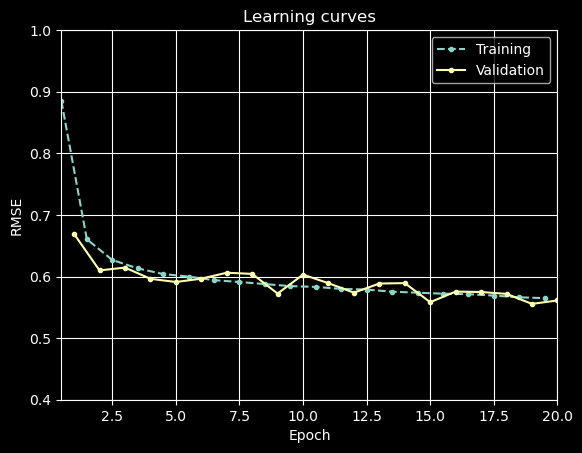

In [164]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                 n_epochs)

# Since we compute the training metric
plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis([0.5, 20, 0.4, 1.0])
plt.legend()
plt.show()